# Definitions

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
os.environ['OMP_NUM_THREADS'] = '10'
import matplotlib
import math
import warnings
from matplotlib import pyplot as plt
import numpy as np
import euclidemu2
import scipy
import cosmolike_roman_real_interface as ci
from getdist import IniFile
import itertools
import iminuit
import functools
from scipy.interpolate import interp1d
print(sys.version)
print(os.getcwd())

# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'

# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# BE CAREFUL: you need texlive-latex-base texlive-latex-extra texlive-fonts-recommended dvipng ghostscript cm-super
matplotlib.rcParams['text.usetex'] = True
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------------------------------------

# Jupyter Notebook Display options
import IPython
IPython.display.display(IPython.display.HTML("<style>:root { --jp-notebook-max-width: 85% !important; }</style>"))
IPython.display.display(IPython.display.HTML("<style>div.output_scroll { height: 54em; }</style>"))

3.10.17 | packaged by conda-forge | (main, Apr 10 2025, 22:23:34) [Clang 18.1.8 ]
/Users/vivianmiranda/data/COCOA/november2025/cocoa/Cocoa/projects/roman_real


In [2]:
# IMPORT CAMB
sys.path.insert(0, os.environ['ROOTDIR']+'/external_modules/code/CAMB/build/lib.linux-x86_64-'+os.environ['PYTHON_VERSION'])
import camb
from camb import model
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))

Using CAMB 1.5.9 installed at /Users/vivianmiranda/data/COCOA/november2025/cocoa/Cocoa/.local/lib/python3.10/site-packages/camb


In [3]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="xi"

path= "../../external_modules/data/roman_real"
data_file="example1.dataset"
ggl_exclude=[[6,0],[7,0],[7,1]]

IA_model = 0
IA_redshift_evolution = 3

ntheta = 15
theta_min_arcmin = 2.5 
theta_max_arcmin = 250
lmax = 70000

In [4]:
As_1e9 = 2.1
ns = 0.96605
H0 = 67.32
omegab = 0.04
omegam = 0.3
mnu = 0.06
w = -1.0
w0pwa = -1.0
roman_A1_1 = 0.6
roman_A1_2 = -1.5
roman_DZ_S1 = 0.0
roman_DZ_S2 = 0.0
roman_DZ_S3 = 0.0
roman_DZ_S4 = 0.0
roman_DZ_S5 = 0.0
roman_DZ_S6 = 0.0
roman_DZ_S7 = 0.0
roman_DZ_S8 = 0.0
roman_M1 = 0.0
roman_M2 = 0.0
roman_M3 = 0.0
roman_M4 = 0.0
roman_M5 = 0.0
roman_M6 = 0.0
roman_M7 = 0.0
roman_M8 = 0.0

In [5]:
def get_camb_cosmology(omegam = omegam, 
                       omegab = omegab, 
                       H0 = H0, 
                       ns = ns, 
                       As_1e9 = As_1e9, 
                       w = w, 
                       w0pwa = w0pwa, 
                       AccuracyBoost=1.0, 
                       kmax=10.0, 
                       k_per_logint=10, 
                       CAMBAccuracyBoost=1.0,
                       non_linear_emul=non_linear_emul,
                       lens_potential_accuracy=1.0,
                       halofit_version='takahashi'):

    As = lambda As_1e9: 1e-9 * As_1e9
    wa = lambda w0pwa, w: w0pwa - w
    omegabh2 = lambda omegab, H0: omegab*(H0/100)**2
    omegach2 = lambda omegam, omegab, mnu, H0: (omegam-omegab)*(H0/100)**2-(mnu*(3.046/3)**0.75)/94.0708
    omegamh2 = lambda omegam, H0: omegam*(H0/100)**2

    CAMBAccuracyBoost = CAMBAccuracyBoost*(1.0 + (AccuracyBoost-1.0)/3.0)
    lens_potential_accuracy = lens_potential_accuracy*CAMBAccuracyBoost
    kmax = kmax*(1.0 + 3*(CAMBAccuracyBoost-1))
    k_per_logint = int(k_per_logint) + int(3*(CAMBAccuracyBoost-1))
    extrap_kmax=2.5e2*CAMBAccuracyBoost

    tmp=int(1000 + 250*CAMBAccuracyBoost)
    z_interp_1D = np.concatenate((np.linspace(0.0,3.0,max(100,int(0.80*tmp))),
                                  np.linspace(3.0,50.1,max(100,int(0.40*tmp))),
                                  np.linspace(50.1,1070,max(50,int(0.10*tmp))),
                                  np.linspace(1070,1100,max(50,int(0.10*tmp)))),axis=0)
    len_z_interp_1D = len(z_interp_1D)
    
    tmp=int(130)
    z_interp_2D = np.concatenate((np.linspace(0,3.,max(50,int(0.75*tmp))), 
                                  np.linspace(3.01,50.1,max(30,int(0.25*tmp)))),axis=0)
    len_z_interp_2D = len(z_interp_2D)
    
    tmp=int(1250+250*CAMBAccuracyBoost)
    log10k_interp_2D = np.linspace(-4.99,2.0,tmp)
    len_log10k_interp_2D = len(log10k_interp_2D)
    
    pars = camb.set_params(H0=H0, 
                           ombh2=omegabh2(omegab, H0), 
                           omch2=omegach2(omegam, omegab, mnu, H0), 
                           mnu=mnu, 
                           omk=0, 
                           tau=0.06,  
                           As=As(As_1e9), 
                           ns=ns, 
                           halofit_version=halofit_version, 
                           lmax=10,
                           AccuracyBoost=CAMBAccuracyBoost,
                           lens_potential_accuracy=lens_potential_accuracy,
                           num_massive_neutrinos=1,
                           nnu=3.046,
                           accurate_massive_neutrino_transfers=False,
                           k_per_logint=k_per_logint,
                           kmax = kmax);
    pars.set_dark_energy(w=w, wa=wa(w0pwa, w), dark_energy_model='ppf');    
    pars.NonLinear = model.NonLinear_both
    pars.set_matter_power(redshifts=z_interp_2D, kmax=kmax, silent=True);
    
    results = camb.get_results(pars)
    
    PKL  = results.get_matter_power_interpolator(var1="delta_tot", 
                                                 var2="delta_tot", 
                                                 nonlinear=False, 
                                                 extrap_kmax=extrap_kmax, 
                                                 hubble_units = False, 
                                                 k_hunit = False);
    PKNL = results.get_matter_power_interpolator(var1="delta_tot", 
                                                 var2="delta_tot",  
                                                 nonlinear=True, 
                                                 extrap_kmax=extrap_kmax, 
                                                 hubble_units=False, 
                                                 k_hunit=False);
    
    lnPL = np.log(PKL.P(z_interp_2D,np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3) 
    
    if non_linear_emul == 1:
        params = { 'Omm'  : omegam, 
                   'As'   : As(As_1e9), 
                   'Omb'  : omegab,
                   'ns'   : ns, 
                   'h'    : H0/100., 
                   'mnu'  : mnu,  
                   'w'    : w, 
                   'wa'   : wa(w0pwa, w)
                 }
        kbt, tmp_bt = euclidemu2.get_boost(params,z_interp_2D[z_interp_2D < 10.0],10**np.linspace(-2.0589,0.973,len_log10k_interp_2D))
        bt = np.array(tmp_bt, dtype='float64')  
        tmp = interp1d(np.log10(kbt), 
                        np.log(bt), 
                        axis=1,
                        kind='linear', 
                        fill_value='extrapolate', 
                        assume_sorted=True)(log10k_interp_2D-np.log10(H0/100.)) #h/Mpc
        tmp[:,10**(log10k_interp_2D-np.log10(H0/100)) < 8.73e-3] = 0.0
        lnbt = np.zeros((len_z_interp_2D, len_log10k_interp_2D))
        lnbt[z_interp_2D < 10.0, :] = tmp
        # Use Halofit first that works on all redshifts
        lnPNL = np.log(PKNL.P(z_interp_2D, np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3) 
        # on z < 10.0, replace it with EE2
        lnPNL = np.where((z_interp_2D<10)[:,None], lnPL.reshape(len_z_interp_2D, len_log10k_interp_2D, order='F') + lnbt, 
                                                   lnPNL.reshape(len_z_interp_2D, len_log10k_interp_2D, order='F')).ravel(order='F')
    elif non_linear_emul == 2:
        lnPNL = np.log(PKNL.P(z_interp_2D, np.power(10.0, log10k_interp_2D)).flatten(order='F')) + np.log((H0/100.0)**3)  
    log10k_interp_2D = log10k_interp_2D - np.log10(H0/100.)
   
    G_growth = np.sqrt(PKL.P(z_interp_2D, 0.0005)/PKL.P(0, 0.0005))*(1 + z_interp_2D)
    G_growth = G_growth/G_growth[len(G_growth)-1]
    
    chi = results.comoving_radial_distance(z_interp_1D) * (H0/100.)
    
    return (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi)

In [6]:
def C_ss_tomo_limber(ell, 
                     omegam = omegam, 
                     omegab = omegab, 
                     H0 = H0, 
                     ns = ns, 
                     As_1e9 = As_1e9, 
                     w = w, 
                     w0pwa = w0pwa,
                     A1  = [roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0], 
                     A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                     BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                     shear_photoz_bias = [roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, 
                                          roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8],
                     M = [roman_M1, roman_M2, roman_M3, roman_M4, 
                          roman_M5, roman_M6, roman_M7, roman_M8],
                     baryon_sims = None,
                     AccuracyBoost = 1.0, 
                     kmax = 10.0, 
                     k_per_logint = 10, 
                     CAMBAccuracyBoost=1.0,
                     CLAccuracyBoost = 1.0, 
                     CLIntegrationAccuracy=0,
                     non_linear_emul=non_linear_emul,
                     allsims=None):
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))

    ci.set_cosmology(omegam=omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    if baryon_sims is not None and allsims is not None:
        ci.init_baryons_contamination(sim = baryon_sims, allsims=allsims)
    return ci.C_ss_tomo_limber(l = ell)

In [7]:
def xi(ntheta = ntheta, 
       theta_min_arcmin = theta_min_arcmin, 
       theta_max_arcmin = theta_max_arcmin, 
       omegam = omegam, 
       omegab = omegab, 
       H0 = H0, 
       ns = ns, 
       As_1e9 = As_1e9, 
       w = w, 
       w0pwa = w0pwa,
       A1  = [roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0], 
       A2  = [0, 0, 0, 0, 0, 0, 0, 0],
       BTA = [0, 0, 0, 0, 0, 0, 0, 0],
       shear_photoz_bias = [roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8],
       M = [roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6, roman_M7, roman_M8],
       baryon_sims = None,
       AccuracyBoost=1.0, 
       kmax=10.0, 
       k_per_logint=10, 
       CAMBAccuracyBoost=1.0,
       CLAccuracyBoost=1.0, 
       CLIntegrationAccuracy=0,
       non_linear_emul=non_linear_emul,
       allsims=None):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(50000+10000*CLAccuracyBoost))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    
    ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    if baryon_sims is not None and allsims is not None:
        ci.init_baryons_contamination(sim = baryon_sims, allsims=allsims)
    (xip, xim) = ci.xi_pm_tomo()    
    return (ci.get_binning_real_space(), xip, xim)

In [8]:
# Init Cosmolike
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))
lens_file = ini.relativeFileName('nz_lens_file')
source_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")
allsims = ini.relativeFileName('all_sims_hdf5_file')
ci.initial_setup()
ci.init_ggl_exclude(np.array(ggl_exclude).flatten())
ci.init_ntable_lmax(lmax=int(lmax))
ci.init_accuracy_boost(1.0, int(1))
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(lens_multihisto_file=lens_file, lens_ntomo=int(lens_ntomo), source_multihisto_file=source_file, source_ntomo=int(source_ntomo))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))

[2025-12-14 23:14:42.635] [info] init_ntomo_powerspectra: GGL pair L6-S0 is excluded
[2025-12-14 23:14:42.635] [info] init_ntomo_powerspectra: GGL pair L7-S0 is excluded
[2025-12-14 23:14:42.635] [info] init_ntomo_powerspectra: GGL pair L7-S1 is excluded


# Basic Plot routines

In [8]:
def plot_C_ss_tomo_limber(ell, C_ss, C_ss_ref = None, param = None, colorbarlabel = None, lmin = 30, lmax = 1500, colorbarshrink=0.3,
                          cmap = 'gist_rainbow', ylim = [0.75,1.25], linestyle = None, linewidth = None,
                          legend = None, legendloc = (0.6,0.78), yaxislabelsize = 12, yaxisticklabelsize = 10, 
                          xaxisticklabelsize = 6, bintextpos = [0.2, 0.85], bintextsize = 13, figsize = (18, 18), 
                          show = 1, colorbar=1, wspace=0.25, hspace=0.05):

    nell, ntomo, ntomo2 = C_ss[0].shape
    if ntomo != ntomo2:
        print("Bad Input (ntomo)")
        return 0
      
    if nell != len(ell):
        print("Bad Input (number of ell)")
        return 0
    if not (C_ss_ref is None):
        nell2, ntomo3, ntomo4 = C_ss_ref.shape
        if (ntomo3 != ntomo4) or (nell != nell2):
            print(f"notomo = {ntomo}, ntomo_REF = {ntomo3}")
            print(f"Nell = {nell}, Nell_REF = {nell2}")
            return 0   
        
    if C_ss_ref is None:
        fig, axes = plt.subplots(
            nrows = ntomo, 
            ncols = ntomo, 
            figsize = figsize, 
            sharex = True, 
            sharey = False, 
            gridspec_kw = {'wspace': wspace, 'hspace': hspace})
    else:
        fig, axes = plt.subplots(
            nrows = ntomo, 
            ncols = ntomo, 
            figsize = figsize, 
            sharex = True, 
            sharey = True, 
            gridspec_kw = {'wspace': 0, 'hspace': 0})
    
    cm = plt.get_cmap(cmap)
    
    if not (param is None or colorbar is None):
        cb = fig.colorbar(
            matplotlib.cm.ScalarMappable(norm = matplotlib.colors.Normalize(param[0], param[-1]), cmap = 'gist_rainbow'), 
            ax = axes.ravel().tolist(), 
            orientation = 'vertical', 
            aspect = 50, 
            pad = -0.16, 
            shrink = colorbarshrink)
        if not (colorbarlabel is None):
            cb.set_label(label = colorbarlabel, size = 18, weight = 'bold', labelpad = 2)
        if len(param) != len(C_ss):
            print("Bad Input")
            return 0

    if not (linestyle is None):
        linestylecycler = itertools.cycle(linestyle)
    else:
        linestylecycler = itertools.cycle(['solid'])

    if not (linewidth is None):
        linewidthcycler = itertools.cycle(linewidth)
    else:
        linewidthcycler = itertools.cycle([1.0])
    
    for i in range(ntomo):
        for j in range(ntomo):
            if i>j:                
                axes[j,i].axis('off')
            else:
                clmin = []
                clmax = []
                for Cl in C_ss:  
                    tmp = ell * (ell + 1) * Cl[:,i,j] / (2 * math.pi)
                    clmin.append(np.min(tmp))
                    clmax.append(np.max(tmp))
     
                axes[j,i].set_xlim([lmin, lmax])
                
                if C_ss_ref is None:
                    axes[j,i].set_ylim([np.min(ylim[0]*np.array(clmin)), np.max(ylim[1]*np.array(clmax))])
                    axes[j,i].set_yscale('log')
                else:
                    tmp = np.array(ylim) - 1
                    axes[j,i].set_ylim(tmp.tolist())
                    axes[j,i].set_yscale('linear')
                    
                axes[j,i].set_xscale('log')
                
                if i == 0:
                    if C_ss_ref is None:
                        axes[j,i].set_ylabel("$\ell (\ell+1) C_{\ell}^{EE}/(2 \pi)$", fontsize=yaxislabelsize)
                    else:
                        axes[j,i].set_ylabel("frac. diff.", fontsize=yaxislabelsize)
                for item in (axes[j,i].get_yticklabels()):
                    item.set_fontsize(yaxisticklabelsize)
                for item in (axes[j,i].get_xticklabels()):
                    item.set_fontsize(xaxisticklabelsize)
                
                if j == ntomo-1:
                    axes[j,i].set_xlabel(r"$\ell$", fontsize=16)
                
                axes[j,i].text(bintextpos[0], bintextpos[1], 
                    "$(" +  str(i) + "," +  str(j) + ")$", 
                    horizontalalignment = 'center', 
                    verticalalignment = 'center',
                    fontsize = bintextsize,
                    usetex = True,
                    transform = axes[j,i].transAxes)
                
                for x, Cl in enumerate(C_ss):
                    if C_ss_ref is None:
                        tmp = ell * (ell + 1) * Cl[:,i,j] / (2 * math.pi)
                    else:
                        tmp = Cl[:,i,j] / C_ss_ref[:,i,j] - 1
                    lines = axes[j,i].plot(ell, tmp, 
                                           color=cm(x/len(C_ss)), 
                                           linewidth=next(linewidthcycler), 
                                           linestyle=next(linestylecycler))
    
    if not (legend is None):
        if len(legend) != len(C_ss):
            print("Bad Input")
            return 0
        fig.legend(
            legend, 
            loc=legendloc,
            borderpad=0.1,
            handletextpad=0.4,
            handlelength=1.5,
            columnspacing=0.35,
            scatteryoffsets=[0],
            frameon=False)

    if not (show is None):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fig.show()
    else:
        return (fig, axes)

In [9]:
def plot_xi(pm, xi, xi_ref = None, param = None, colorbarlabel = None, marker = None, colorbarshrink=0.3,
                linestyle = None, linewidth = None, ylim = [0.88,1.12], 
                cmap = 'gist_rainbow', legend = None, legendloc = (0.6,0.78), yaxislabelsize = 10, 
                yaxisticklabelsize = 6, xaxisticklabelsize = 20, bintextpos = [[0.8, 0.875],[0.2,0.875]], 
                bintextsize = 15, figsize = (18, 18), show = 1, thetashow=[3,250], colorbar=1, wspace=0.25,hspace=0.05):
    
    (theta, xip, xim) = xi[0]
    (ntheta, ntomo, ntomo2) = xip.shape    

    if ntomo != ntomo2:
        print("Bad Input (ntomo)")
        return 0
            
    if ntheta != len(theta):
        print("Bad Input (theta)")
        return 0

    if xi_ref is None:
        fig, axes = plt.subplots(
            nrows = ntomo, 
            ncols = ntomo, 
            figsize = figsize, 
            sharex = True, 
            sharey = False, 
            gridspec_kw = {'wspace': wspace, 'hspace': hspace}
        )
    else:
        fig, axes = plt.subplots(
            nrows = ntomo, 
            ncols = ntomo, 
            figsize = figsize, 
            sharex = True, 
            sharey = True, 
            gridspec_kw = {'wspace': 0.0, 'hspace': 0.0}
        )    

    cm = plt.get_cmap(cmap)

    if not (param is None or colorbar is None):
        cb = fig.colorbar(
            matplotlib.cm.ScalarMappable(norm = matplotlib.colors.Normalize(param[0], param[-1]), cmap = 'gist_rainbow'), 
            ax = axes.ravel().tolist(), 
            orientation = 'vertical', 
            aspect = 50, 
            pad = -0.16, 
            shrink = colorbarshrink
        )
        if not (colorbarlabel is None):
            cb.set_label(label = colorbarlabel, size = 20, weight = 'bold', labelpad = 2)
        if len(param) != len(xi):
            print("Bad Input")
            return 0

    if not (marker is None):
        markercycler = itertools.cycle(marker)
    
    if not (linestyle is None):
        linestylecycler = itertools.cycle(linestyle)
    else:
        linestylecycler = itertools.cycle(['solid'])
    
    if not (linewidth is None):
        linewidthcycler = itertools.cycle(linewidth)
    else:
        linewidthcycler = itertools.cycle([1.0])
        
    for i in range(ntomo):
        for j in range(ntomo):
            if i>j:                
                axes[j,i].axis('off')
            else:
                ximin = []
                ximax = []
                for (theta, xip, xim) in xi:
                    if pm > 0:
                        ximin.append(np.min(theta*xip[:,i,j]*10**4))
                        ximax.append(np.max(theta*xip[:,i,j]*10**4))
                    else:
                        ximin.append(np.min(theta*xim[:,i,j]*10**4))
                        ximax.append(np.max(theta*xim[:,i,j]*10**4))
                        
                axes[j,i].set_xlim(thetashow)
                
                if xi_ref is None:
                    axes[j,i].set_ylim([np.min(ylim[0]*np.array(ximin)), np.max(ylim[1]*np.array(ximax))])
                else:
                    tmp = np.array(ylim) - 1
                    axes[j,i].set_ylim(tmp.tolist())
                axes[j,i].set_xscale('log')
                axes[j,i].set_yscale('linear')
                
                if i == 0:
                    if xi_ref is None:
                        if pm > 0:
                            axes[j,i].set_ylabel(r"$\theta \xi_{+} \times 10^4$", fontsize=yaxislabelsize)
                        else:
                            axes[j,i].set_ylabel(r"$\theta \xi_{-} \times 10^4$", fontsize=yaxislabelsize)
                    else:
                        if pm > 0:
                            axes[j,i].set_ylabel(r"frac. diff. ($\xi_{+})$", fontsize=yaxislabelsize)
                        else:
                            axes[j,i].set_ylabel(r"frac. diff. ($\xi_{-})$", fontsize=yaxislabelsize)

                if j == ntomo-1:
                    axes[j,i].set_xlabel(r"$\theta$ [arcmin]", fontsize=16)
                for item in (axes[j,i].get_yticklabels()):
                    item.set_fontsize(yaxisticklabelsize)
                for item in (axes[j,i].get_xticklabels()):
                    item.set_fontsize(xaxisticklabelsize)

                if pm > 0:
                    axes[j,i].text(bintextpos[0][0], 
                                   bintextpos[0][1], 
                                   "$(" +  str(i) + "," +  str(j) + ")$", 
                                   horizontalalignment='center', 
                                   verticalalignment='center',
                                   fontsize=bintextsize,
                                   usetex=True,
                                   transform=axes[j,i].transAxes)
                else:
                    axes[j,i].text(bintextpos[1][0], 
                                   bintextpos[1][1], 
                                   "$(" +  str(i) + "," +  str(j) + ")$", 
                                   horizontalalignment='center', 
                                   verticalalignment='center',
                                   fontsize=15,
                                   usetex=True,
                                   transform=axes[j,i].transAxes)

                if xi_ref is None:
                    for x, (theta, xip, xim) in enumerate(xi):
                        if pm > 0:
                            if marker is None:
                                axes[j,i].plot(theta, theta*xip[:,i,j]*10**4, color=cm(x/len(xi)), 
                                               linewidth=next(linewidthcycler), linestyle=next(linestylecycler))
                            else:
                                axes[j,i].plot(theta, theta*xip[:,i,j]*10**4, color=cm(x/len(xi)), 
                                               markerfacecolor='None', marker=next(markercycler), 
                                               markeredgecolor=cm(x/len(xi)), linestyle='None', markersize=3)
                        else:
                            if marker is None:   
                                axes[j,i].plot(theta, theta*xim[:,i,j]*10**4, color=cm(x/len(xi)), 
                                    linewidth=next(linewidthcycler), linestyle=next(linestylecycler))
                            else:
                                axes[j,i].plot(theta, theta*xim[:,i,j]*10**4, color=cm(x/len(xi)), 
                                               markerfacecolor='None', marker=next(markercycler), 
                                               markeredgecolor=cm(x/len(xi)), linestyle='None', markersize=3)
                else:
                    (theta_ref, xip_ref, xim_ref) = xi_ref
                    for x, (theta, xip, xim) in enumerate(xi):
                        if theta != theta_ref:
                            print("inconsistent theta bins")
                            return 0
                        if pm > 0:
                            if marker is None:
                                axes[j,i].plot(theta, xip[:,i,j]/xip_ref[:,i,j]-1.0, color=cm(x/len(xi)), 
                                               linewidth=next(linewidthcycler), linestyle=next(linestylecycler))
                            else:
                                axes[j,i].plot(theta, xip[:,i,j]/xip_ref[:,i,j]-1.0, 
                                               color=cm(x/len(xi)), markerfacecolor='None',
                                               marker=next(markercycler),  markeredgecolor=cm(x/len(xi)), 
                                               linestyle='None', markersize=3)
                        else:
                            if marker is None:   
                                lines = axes[j,i].plot(theta, xip[:,i,j]/xip_ref[:,i,j]-1.0, color=cm(x/len(xi)), 
                                                       linewidth=next(linewidthcycler), linestyle=next(linestylecycler))
                            else:
                                axes[j,i].plot(theta, xip[:,i,j]/xip_ref[:,i,j]-1.0, color=cm(x/len(xi)), 
                                               markerfacecolor='None', marker=next(markercycler), 
                                               markeredgecolor=cm(x/len(xi)), 
                                               linestyle='None', markersize=3)    
    if not (legend is None):
        if len(legend) != len(xi):
            print("Bad Input")
            return 0
        fig.legend(legend, 
                   loc=legendloc,
                   borderpad=0.1,
                   handletextpad=0.4,
                   handlelength=1.5,
                   columnspacing=0.35,
                   scatteryoffsets=[0],
                   frameon=False)  
    if not (show is None):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            fig.show()
    else:
        return (fig, axes)

# Let's plot how cosmological and nuisance parameters affect $C_{\ell}^{EE}$

In [37]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(0.2, 0.4, 0.02)     
C_ss = []
for x in param:
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, omegam=x)
    C_ss.append(Cl)

In [ ]:
plot_C_ss_tomo_limber(ell=ell, C_ss=C_ss, param=param, colorbarlabel="$\Omega_m$", yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, 
                      figsize = (18, 13), lmin = lmin, lmax = lmax, wspace=0.4)

In [ ]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin,lmax, 20.) # Make sure arange are with float numbers (otherwise there are aliasing problems)
param = np.arange(0.85, 1.1, 0.02)
C_ss = []
for x in param:
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, ns=x)
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(ref, tmp) = C_ss_tomo_limber(ell=ell)

In [ ]:
plot_C_ss_tomo_limber(ell=ell, C_ss=C_ss, C_ss_ref=ref, param=param, colorbarlabel="$n_s$", figsize = (18, 13), yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10,
                     lmin = lmin, lmax = lmax, ylim = [0.7,1.3], wspace=0.4)

# Let's plot how cosmological and nuisance parameters affect $\xi(\theta)$

In [ ]:
param = np.arange(0.2, 0.4, 0.02)
xi_theta = []
for x in param:
    xi_theta.append(xi(omegam = x))

In [ ]:
plot_xi(pm = 1, xi = xi_theta, param = param, colorbarlabel = "$\Omega_m$", yaxislabelsize = 10, xaxisticklabelsize=10, yaxisticklabelsize=10,
        figsize = (18, 14), thetashow=[2.5,250], wspace=0.3)

In [ ]:
plot_xi(pm = -1, xi = xi_theta, param = param, colorbarlabel = "$\Omega_m$", yaxislabelsize = 10, xaxisticklabelsize=10, yaxisticklabelsize=10,
        figsize = (18, 13), thetashow=[2.5,250], wspace=0.3)

# Can we change the binning on $\xi(\theta)$ w/o restarting the kernel? Yes!
Why this is a nontrivial question? Because Cosmolike uses static variables to cache Glplus and Glminus

In [ ]:
nthetas=[9, 12, 17, 44]
result = []
for x in nthetas:
    result.append(xi(ntheta=x))

In [ ]:
plot_xi(pm = 1, xi = result, marker=['s', 'o', ">", "<"], yaxislabelsize = 10, xaxisticklabelsize=10, yaxisticklabelsize=10, 
        figsize = (18, 12), thetashow=[2.5,250], wspace=0.3)

In [ ]:
plot_xi(pm = -1, xi = result, marker=['s', 'o', ">", "<"], yaxislabelsize = 10, xaxisticklabelsize=10, yaxisticklabelsize=10, 
        figsize = (18, 12), thetashow=[2.5,250], wspace=0.3)

# Add Baryon Contamination to $C_\ell^{\rm EE}$ and $\xi(\theta)$ data vectors

In [ ]:
lmin = 100.
lmax = 4500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = ("TNG100-1", "HzAGN-1", "mb2-1", "illustris-1", "eagle-1", "owls_AGN-1", "owls_AGN-2", "owls_AGN-3", "BAHAMAS-2")
C_ss = []
for x in param:
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, baryon_sims=x,allsims=allsims)
    C_ss.append(Cl)
    
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = C_ss_tomo_limber(ell=ell)

xi_theta = []
for x in param:
    xi_theta.append(xi(baryon_sims=x,allsims=allsims, ntheta=40, AccuracyBoost=1.0))

xi_theta_ref = xi(ntheta=40, AccuracyBoost=1.0)

In [ ]:
plot_C_ss_tomo_limber(ell=ell, C_ss=C_ss,  C_ss_ref=C_ss_ref, lmin=lmin, lmax=lmax, cmap="twilight_shifted", yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, 
                      ylim=(0.6,1.3), figsize = (18, 12), wspace=0.4)

In [ ]:
matplotlib.rcParams['legend.fontsize'] = 17
plot_xi(pm = 1, param=None, xi=xi_theta,  xi_ref=xi_theta_ref, cmap="twilight_shifted", 
        ylim=(0.81,1.09), linewidth=[1.0, 1.3, 1.6, 1.9], 
        linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
        legend = param, legendloc=(0.7,0.55), bintextpos = [[0.2, 0.875],[0.2,0.875]], 
        yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, figsize = (18, 13), wspace=0.4)

In [ ]:
plot_xi(pm = -1, param=None, xi=xi_theta,  xi_ref=xi_theta_ref, cmap="twilight_shifted", 
            ylim=(0.81,1.09), linewidth=[1.0, 1.3, 1.6, 1.9], 
            linestyle = ['solid', 'dashed', 'dashdot', 'dotted'],
            legend = param, legendloc=(0.7,0.55), bintextpos = [[0.2, 0.875],[0.2,0.875]], 
            yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, figsize = (18, 12), wspace=0.4)

# Check how CAMB and Cosmolike Accuracy Boost affect $C_\ell^{\rm EE}$ and $\xi(\theta)$ data vectors (and $\chi^2)$

In [ ]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(1.0, 10.0, 0.5)
C_ss = []
for x in param:
    # Change only Cosmolike Settings
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x))
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

In [ ]:
plot_C_ss_tomo_limber(ell=ell, C_ss=C_ss,  C_ss_ref=C_ss_ref, param=param, lmin=lmin, 
                      lmax=lmax, ylim=(0.9985,1.0015), colorbarlabel="Accuracy Boost",
                      yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, figsize = (18, 11), wspace=0.4)

In [ ]:
param = np.arange(0,10.0,1.0)
xi_theta_ref = xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=1)
xi_theta = []
for x in param:
    xi_theta.append(xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1+x,CLIntegrationAccuracy=int(x)))

In [ ]:
plot_xi(pm=0, xi=xi_theta, xi_ref=xi_theta_ref, param=param, ylim=(0.98,1.02),
        yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, figsize = (18, 11), wspace=0.4)

In [ ]:
plot_xi(pm=1, xi=xi_theta, xi_ref=xi_theta_ref, param=param, ylim=(0.98,1.02),
       yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, figsize = (18, 11), wspace=0.4)

In [ ]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 30.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = np.arange(1.,6.0,1.0)
C_ss = []
for x in param:
    # Change only CAMB Settings
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
    C_ss.append(Cl)
# Plot the Ratio over ref cosmology
(C_ss_ref, tmp) = C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)

In [ ]:
plot_C_ss_tomo_limber(ell=ell, C_ss=C_ss,  C_ss_ref=C_ss_ref, param=param, lmin=lmin, 
                      lmax=lmax, ylim=(0.965,1.035),  colorbarlabel="Accuracy Boost",
                      yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, figsize = (18, 11), wspace=0.4)

In [ ]:
param = np.arange(1.,6.0,1.0)
xi_theta_ref = xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0)
xi_theta = []
for x in param:
    xi_theta.append(xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0))

In [ ]:
plot_xi(pm = 1, xi = xi_theta, xi_ref = xi_theta_ref, param=param,ylim=(0.99, 1.01),
        yaxislabelsize = 10, xaxisticklabelsize=10,yaxisticklabelsize=10, figsize = (18, 11), wspace=0.4)

# Let's compute $\chi^2_{\rm Roman Real}$ and reproduce the results shown on EXAMPLE_EVALUATE1.YAML

In [178]:
CAMBAccuracyBoost = 1.0
non_linear_emul = 2
CLprobe="xi"
ntheta = 15
theta_min_arcmin = 2.5 
theta_max_arcmin = 250
path= "../../external_modules/data/roman_real"
data_file="example1.dataset"
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))
lens_file = ini.relativeFileName('nz_lens_file')
source_file = ini.relativeFileName('nz_source_file')
lens_ntomo = ini.int("lens_ntomo")
source_ntomo = ini.int("source_ntomo")
allsims = ini.relativeFileName('all_sims_hdf5_file')
ggl_exclude=[[6,0],[7,0],[7,1]]
IA_model = 0
IA_redshift_evolution = 3
ci.initial_setup()
ci.init_ggl_exclude(np.array(ggl_exclude).flatten())
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(
      lens_multihisto_file=ini.relativeFileName('nz_lens_file'),
      lens_ntomo=int(ini.int("lens_ntomo")), 
      source_multihisto_file=ini.relativeFileName('nz_source_file'),
      source_ntomo=int(ini.int("source_ntomo")))
ci.init_IA(ia_model = int(IA_model), 
           ia_redshift_evolution = int(IA_redshift_evolution))
# Init Cosmolike
ci.init_probes(possible_probes = CLprobe)
ci.init_binning(int(ini.int("n_theta")), 
                ini.float("theta_min_arcmin"), 
                ini.float("theta_max_arcmin"))
ci.init_data_real(ini.relativeFileName('cov_file'), 
                  ini.relativeFileName('mask_file'), 
                  ini.relativeFileName('data_file'))
def get_chi2(omegam = omegam, 
             omegab = omegab, 
             H0 = H0, 
             ns = ns, 
             As_1e9 = As_1e9, 
             w = w, 
             w0pwa = w0pwa,
             A1  = [roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0], 
             A2  = [0, 0, 0, 0, 0, 0, 0, 0],
             BTA = [0, 0, 0, 0, 0, 0, 0, 0],
             shear_photoz_bias = [roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8],
             M = [roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6, roman_M7, roman_M8],
             baryon_sims = None,
             AccuracyBoost = 1.0, 
             kmax=7.5, 
             k_per_logint=10, 
             CAMBAccuracyBoost=1.0,
             CLAccuracyBoost=1.0, 
             CLIntegrationAccuracy = 0,
             non_linear_emul=non_linear_emul):
   
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(70000+10000*(CLAccuracyBoost-1)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, 
                       A2 = A2, 
                       B_TA = BTA)
    datavector = np.array(ci.compute_data_vector_masked())
    return ci.compute_chi2(datavector)

[2025-12-12 18:38:21.201] [info] init_ntomo_powerspectra: GGL pair L6-S0 is excluded
[2025-12-12 18:38:21.201] [info] init_ntomo_powerspectra: GGL pair L7-S0 is excluded
[2025-12-12 18:38:21.201] [info] init_ntomo_powerspectra: GGL pair L7-S1 is excluded


In [179]:
get_chi2(omegam = 0.3)

0.016022166185272853

In [180]:
param = np.arange(0.295, 0.305, 0.001)      
chi2 = []
for x in param:
    chi2.append(get_chi2(omegam = x))

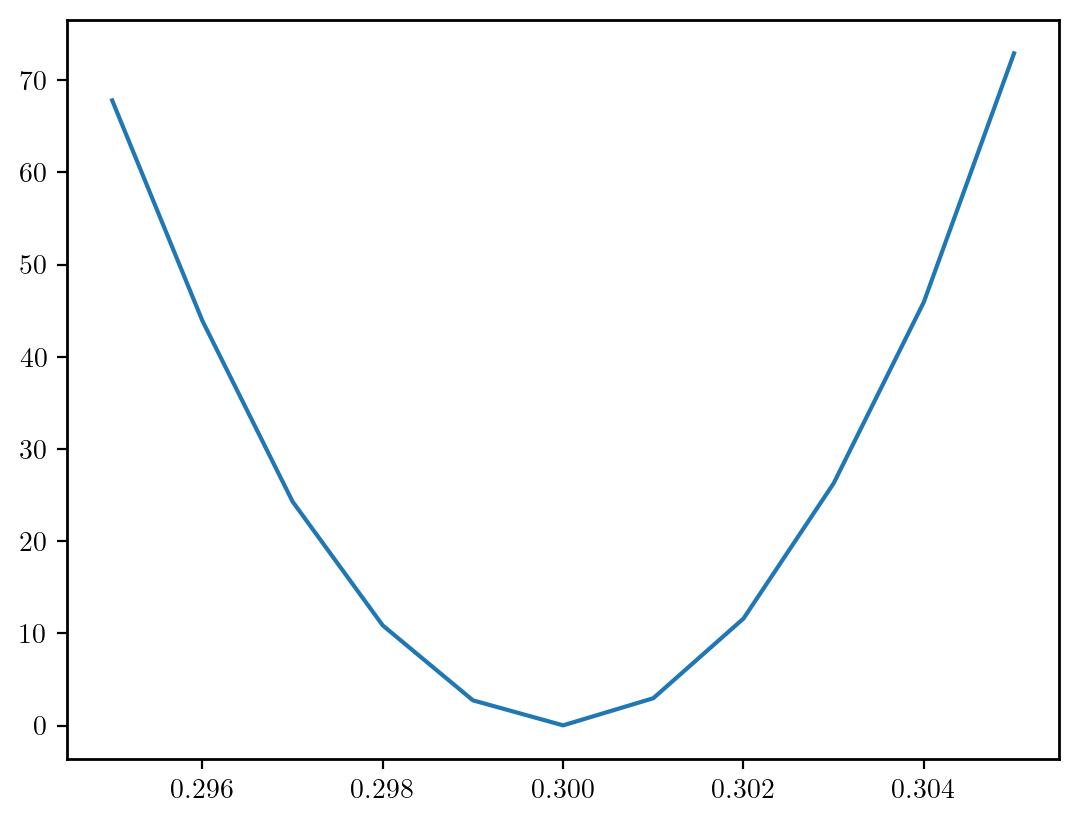

In [181]:
plt.plot(param, chi2)

# Let's compute $\chi^2_{\rm Roman Real}$ as function of CAMB+Cosmolike Integration Accuracy

In [ ]:
param = np.arange(0., 6., 0.5)      
chi2 = []
for x in param:
    chi2.append(get_chi2(AccuracyBoost = 1, CAMBAccuracyBoost = 1.+ x/3.0, CLAccuracyBoost = 1 + x, CLIntegrationAccuracy = 1))
chi2 = np.array(chi2)

In [ ]:
plt.plot(param, np.array(chi2 - chi2[-1]))

In [ ]:
# Do we get the similar behaviour by just changing AccuracyBoost (which we design to change all parameters at once)
param = np.arange(0, 6, 0.5)      
chi2 = []
for x in param:
    chi2.append(get_chi2(AccuracyBoost = 1 + x))
chi2 = np.array(chi2)

In [ ]:
plt.plot(param, np.array(chi2 - chi2[-1]))

# Let's Plot HALOFIT VS EE2

In [ ]:
print(rf"$\chi^2$={get_chi2(non_linear_emul=1):3.3f}")
print(rf"$\chi^2$={get_chi2(non_linear_emul=2):3.3f}")

In [ ]:
lmin = 100.
lmax = 6500.
ell = np.arange(lmin, lmax, 20.) # Make sure np.arange are set w/ float numbers (otherwise there are aliasing problems)
param = [1]
C_ss = []
for x in param:
    # Change only Cosmolike Settings
    (Cl, tmp) = C_ss_tomo_limber(ell=ell, AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
    C_ss.append(Cl)
(C_ss_ref, tmp) = C_ss_tomo_limber(ell=ell,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1)

In [ ]:
# Plot the Ratio over ref cosmology
plot_C_ss_tomo_limber(ell=ell, C_ss=C_ss,  C_ss_ref=C_ss_ref, param=param, lmin=lmin, 
                      lmax=lmax, ylim=(0.95,1.05),  colorbarlabel="Accuracy Boost", colorbar=None,
                      yaxislabelsize = 10, xaxisticklabelsize=10, yaxisticklabelsize=10,figsize = (18, 13), wspace=0.3)

In [ ]:
param = [1]
xi_theta_ref = xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1.,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=2)
xi_theta = []
for x in param:
    xi_theta.append(xi(ntheta=40,AccuracyBoost=1,CAMBAccuracyBoost=1+x/3,CLAccuracyBoost=1,CLIntegrationAccuracy=0,non_linear_emul=1))

In [ ]:
plot_xi(pm = 1, xi = xi_theta, xi_ref = xi_theta_ref,param=param,ylim=(0.965, 1.035), colorbar=None,
       yaxislabelsize = 10, xaxisticklabelsize=10, yaxisticklabelsize=10,figsize = (18, 13), thetashow=[2.5,250], wspace=0.3)

# Let's investigate Fisher

In [ ]:
from getdist import plots
from getdist.mcsamples import MCSamples
from derivkit import adaptive_fit

rng = np.random.default_rng(0)
IA_model = 0
IA_redshift_evolution = 3
ini = IniFile(os.path.normpath(os.path.join(path, data_file)))
ci.initial_setup()
ci.init_ggl_exclude(np.array(ggl_exclude).flatten())
ci.init_accuracy_boost(1.0, 1)
ci.init_cosmo_runmode(is_linear = False)
ci.init_redshift_distributions_from_files(lens_multihisto_file=ini.relativeFileName('nz_lens_file'),
                                          lens_ntomo=int(ini.int("lens_ntomo")), 
                                          source_multihisto_file=ini.relativeFileName('nz_source_file'),
                                          source_ntomo=int(ini.int("source_ntomo")))
ci.init_IA(ia_model = int(IA_model), ia_redshift_evolution = int(IA_redshift_evolution))
ci.init_probes(possible_probes = CLprobe)
ci.init_binning(int(ini.int("n_theta")), 
                ini.float("theta_min_arcmin"), 
                ini.float("theta_max_arcmin"))
ci.init_data_real(ini.relativeFileName('cov_file'), 
                  ini.relativeFileName('mask_file'), 
                  ini.relativeFileName('data_file'))

param = np.array([As_1e9, ns, H0, omegab, omegam, roman_A1_1, roman_A1_2, 
                  roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8, 
                  roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6, roman_M7, roman_M8], dtype="float64")

param_names = [
    "As_1e9", "ns", "H0", "omegab", "omegam", "roman_A1_1", "roman_A1_2",
    "zshift_1", "zshift_2", "zshift_3", "zshift_4", "zshift_5",  "zshift_6", "zshift_7", "zshift_8",
    "M_1", "M_2", "M_3", "M_4", "M_5", "M_6", "M_7", "M_8"
]

param_labels = [
    r"10^{9} A_s", r"n_s", r"H_0", r"\Omega_b", r"\Omega_m",
    r"A_\mathrm{1IA,roman}^1", r"A_\mathrm{1IA,roman}^2",
    r"\Delta z_\mathrm{s,roman}^1", r"\Delta z_\mathrm{s,roman}^2",
    r"\Delta z_\mathrm{s,roman}^3", r"\Delta z_\mathrm{s,roman}^4", r"\Delta z_\mathrm{s,roman}^5",
    r"\Delta z_\mathrm{s,roman}^6", r"\Delta z_\mathrm{s,roman}^7", r"\Delta z_\mathrm{s,roman}^8",
    r"m_\mathrm{roman}^1", r"m_\mathrm{roman}^2", r"m_\mathrm{roman}^3", r"m_\mathrm{roman}^4", r"m_\mathrm{roman}^5",
    r"m_\mathrm{roman}^6", r"m_\mathrm{roman}^7", r"m_\mathrm{roman}^8"
]

flat_priors = {
    0: (0.5, 5),   
    1: (0.87, 1.07),
    2: (55.0, 91.0),
    3: (0.03, 0.07),
    4: (0.1, 0.9),
    5: (-5.0, 5.0),
    6: (-5.0, 5.0)
}

gaussian_priors = {
    15: (0.0, 0.005),   # roman_M1
    16: (0.0, 0.005),
    17: (0.0,  0.005),
    18: (0.0, 0.005),
    19: (0.0, 0.005),  # roman_M5
    20: (0.0, 0.005),
    21: (0.0, 0.005),
    22: (0.0, 0.005),  # roman_M8
    7: (0.0, 0.002),  # roman_DZ_S1
    8: (0.0, 0.002),
    9: (0.0, 0.002),
    10: (0.0, 0.002),
    11: (0.0, 0.002),
    12: (0.0, 0.002),
    13: (0.0, 0.002),
    14: (0.0, 0.002)  # roman_DZ_S8
}

invcov = ci.get_inv_cov_masked()

def get_dv(param=param, AccuracyBoost = 1.0):
    As_1e9 = param[0] 
    ns = param[1] 
    H0 = param[2]
    omegab = param[3] 
    omegam = param[4]
    w = -1.0       # we are ignoring w0wa for this example
    w0pwa = -1.0   # we are ignoring w0wa for this example
    A1  = [param[5], param[6], 0, 0, 0, 0, 0, 0] 
    A2  = [0, 0, 0, 0, 0, 0, 0, 0]
    BTA = [0, 0, 0, 0, 0, 0, 0, 0]
    shear_photoz_bias = [param[7], param[8], param[9], param[10], param[11], param[12], param[13], param[14]]
    M = [param[12], param[13], param[14], param[15], param[16], param[17], param[18], param[19]]
    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost)
    CLAccuracyBoost = AccuracyBoost
    CLIntegrationAccuracy = max(0,abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(lmax+10000*(CLAccuracyBoost-1)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)
    return np.array(ci.compute_data_vector_masked(), dtype=np.float64)

def get_ddv(index=0, h=0.02, CV=param, AccuracyBoost = 1.0):
    assert h > 0.0, "h must be > 0"
    coeffs = np.array([-1.0/12.0, 8.0/12.0, -8.0/12.0, +1.0/12.0], dtype=np.float64)
    steps  = np.array([2*h, h, -h, -2*h], dtype=np.float64)
    p0 = float(CV[index])
    result = None
    for s, c in zip(steps, coeffs):
        p = np.array(CV, dtype = np.float64, copy=True)
        p[index] = p0 + s if np.isclose(p0, 0.0, atol=1e-12) else p0 * (1.0 + s)
        dv = get_dv(param=p, AccuracyBoost=AccuracyBoost)
        result = c*dv if result is None else result + c*dv
    return result / (h if p0 == 0.0 else h * p0) 

def add_gaussian_priors(F, priors):
    Fp = F.copy()
    idxs = np.fromiter(priors.keys(), dtype=int)
    sigmas = np.fromiter((v[1] for v in priors.values()), dtype=float)
    np.add.at(Fp, (idxs, idxs), 1.0 / (sigmas ** 2))
    return Fp
    
def get_Fisher(CV=param, h=0.02, AccuracyBoost=3.1, ddv=get_ddv, priors=gaussian_priors, invcov=invcov):
    D = np.column_stack([ddv(index=p, h=h, CV=CV, AccuracyBoost=AccuracyBoost) for p in list(range(len(CV)))]).astype(np.float64)
    F = D.T @ (invcov @ D)
    if priors is not None:
        F = add_gaussian_priors(F=F, priors=priors)
    return F
    
def get_FoM(i, j, F):
    C = np.linalg.inv(0.5 * (F + F.T)) 
    C = C[np.ix_([i, j], [i, j])]
    detC = np.linalg.det(C)
    if detC <= 0:
        w = np.clip(np.linalg.eigvalsh(C), 0, None)
        detC = w.prod()
    return float(1.0/np.sqrt(detC))

def plot_Fisher(F, mu, F2=None, root=None, select=None, labels=param_labels, names=param_names, filled=True, flat_priors=flat_priors, chain_names=None):
    if select is None:
        select = list(range(len(mu)))
    idx = list(select)

    mu = np.asarray(mu, float)[idx]
    names  = [names[k]  for k in idx]
    labels = [labels[k] for k in idx]

    F = F if isinstance(F, (list, tuple)) else [F]

    samples = []
    for Fi in F:
        Fi = 0.5 * (Fi + Fi.T)
        C = np.linalg.inv(Fi) 
        C = C[np.ix_(idx, idx)]
        y = rng.multivariate_normal(mu, C, size=40000)
        conds = [(y[:,j] >= lo) & (y[:,j] <= hi) for j, (lo, hi) in flat_priors.items()]
        valid = np.all(conds, axis=0) if conds else np.ones(y.shape[0], dtype=bool)
        ranges = {names[j]: [lo, hi] for j, (lo, hi) in flat_priors.items()}
        x = MCSamples(samples=y[valid], names=names, ranges=ranges, labels=labels)
        samples.append(x)
        
    analysissettings={'smooth_scale_1D':0.1, 
                      'smooth_scale_2D':0.1,
                      'ignore_rows': u'0.0',
                      'range_confidence' : u'0.005',
                      'fine_bins_2D': 2048,
                      'bins_2D': 1024,
                      'fine_bins_1D': 512,
                      'bins_1D': 256}

    if F2 is not None:
        F2 = F2 if isinstance(F2, (list, tuple)) else [F2]
        for Fi in F2:
            Fi = 0.5 * (Fi + Fi.T)
            C = np.linalg.inv(Fi) 
            C = C[np.ix_(idx, idx)]
            y = rng.multivariate_normal(mu, C, size=40000)
            conds = [(y[:,j] >= lo) & (y[:,j] <= hi) for j, (lo, hi) in flat_priors.items()]
            valid = np.all(conds, axis=0) if conds else np.ones(y.shape[0], dtype=bool)
            ranges = {names[j]: [lo, hi] for j, (lo, hi) in flat_priors.items()}
            x = MCSamples(samples=y[valid], names=names, ranges=ranges, labels=labels)
            samples.append(x)
    
    if root:
        samples.append(loadMCSamples(root,settings={'ignore_rows': u'0.0'}))
            
    g = plots.get_subplot_plotter(width_inch=10.5,analysis_settings=analysissettings)
    g.settings.axis_tick_x_rotation=65
    g.settings.lw_contour=1.0
    g.settings.legend_rect_border = False
    g.settings.figure_legend_frame = False
    g.settings.axes_fontsize = 16.0
    g.settings.legend_fontsize = 16.5
    g.settings.alpha_filled_add = 0.85
    g.settings.lab_fontsize=15.5
    g.legend_labels=False

    cc  = itertools.cycle(["cornflowerblue", "darkorange", "seagreen", "firebrick", "purple", "gold"])
    lsc = itertools.cycle(["solid", "dashed", "dotted", "dashdot"])
    lwc = itertools.cycle([1.2, 1.5])

    line_args = []
    contour_cols = []
    contour_ls = [] 
    contour_lws = []

    for _ in samples:
        c  = next(cc)
        ls = next(lsc)
        lw = next(lwc)
        line_args.append({'lw': lw, 'ls': ls, 'color': c})
        contour_cols.append(c)
        contour_ls.append(ls)
        contour_lws.append(lw)
            
    g.triangle_plot(samples, 
                    params=names,
                    filled=filled,
                    line_args=line_args,
                    contour_colors=contour_cols,
                    contour_ls=contour_ls,
                    contour_lws=contour_lws,
                   legend_labels=chain_names)
    return g

# derivakit
def get_ddv_dkit(index=0, CV=param, AccuracyBoost = 1.0,  min_samples=7, fallback_mode: str = "poly_at_floor"):
    p0 = float(CV[index])
    def func(x):
        p = np.array(CV, dtype = np.float64, copy=True)
        p[index] = x
        return get_dv(param=p, AccuracyBoost=AccuracyBoost) 
    dk = adaptive_fit.AdaptiveFitDerivative(function=func, central_value=p0)
    return dk.compute(diagnostics=False, min_samples=min_samples, fallback_mode=fallback_mode) 

def get_Fisher2(CV=param, AccuracyBoost=3.0, priors=gaussian_priors, invcov=invcov, min_samples=7, fallback_mode: str = "poly_at_floor"):
    D = np.column_stack([get_ddv_dkit(index=p, CV=CV, AccuracyBoost=AccuracyBoost, min_samples=min_samples, fallback_mode=fallback_mode) for p in list(range(len(CV)))]).astype(np.float64)
    F = D.T @ (invcov @ D)
    if priors is not None:
        F = add_gaussian_priors(F=F, priors=priors)
    return F

### Fisher based on 5-stencil rule - Test Accuracy Boost

In [ ]:
AB1 = np.arange(0, 5.0, 1.0)
FOM1 = []
F1 = []
for x in AB1:
    F = get_Fisher(CV = param, h = 0.03, AccuracyBoost = 1 + x)
    F1.append(F)
    FOM1.append(get_FoM(0, 4, F))

In [ ]:
plt.plot(AB1, FOM1) # This show we need high accuracy boost to do Fisher

In [ ]:
sel = [0, 1, 2, 3, 4, 5, 6]
g = plot_Fisher(F=F1, mu=param, select=sel, filled=True, flat_priors=flat_priors, chain_names=['Accuracy Boost = 1', 'Accuracy Boost = 2', 'Accuracy Boost = 3','Accuracy Boost = 4'])

### Fisher based on 5-stencil rule - Test Step Size

In [ ]:
hs2 = np.arange(0.02, 0.1, 0.01)
F2 = []
FOM2 = []
for x in hs2:
    F = get_Fisher(CV = param, h = x, AccuracyBoost = 3.0)
    F2.append(F)
    FOM2.append(get_FoM(0, 4, F))

In [ ]:
plt.plot(hs2, FOM2) 

In [ ]:
sel = [0, 1, 2, 3, 4, 5, 6]
g = plot_Fisher(F=F2, mu=param, select=sel, filled=True, flat_priors=flat_priors, chain_names=['h=0.02','h=0.03','h=0.04','h=0.05','h=0.06','h=0.07','h=0.08','h=0.09'])

### Fisher based on 5-stencil rule - Test accuracy vs DerivativeKit and true chain?

In [ ]:
F = get_Fisher(CV=param, h=0.06, AccuracyBoost = 3.0)

In [ ]:
F2 = get_Fisher2(CV=param, AccuracyBoost = 2.5)

In [ ]:
sel = [0, 1, 2, 3, 4, 5, 6]
g = plot_Fisher(F=F, F2=F2, mu=param, select=sel, filled=True, root='./example_chains/EXAMPLE_MCMC1_THIN',chain_names=['Fisher (5-point rule)', 'Fisher (Derivakit)', 'MCMC'])

# Plot Reponse Function $d\ln C_{\mathrm{ss}}^{\mathrm{EE}} \big/ d\ln k$ (normalized)

In [9]:
def dlnC_dlss_tomo_limber(k,
                          ell, 
                          omegam = omegam, 
                          omegab = omegab, 
                          H0 = H0, 
                          ns = ns, 
                          As_1e9 = As_1e9, 
                          w = w, 
                          w0pwa = w0pwa,
                          A1  = [roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0], 
                          A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                          BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                          shear_photoz_bias = [roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, 
                                               roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8],
                          M = [roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6, roman_M7, roman_M8],
                          baryon_sims = None,
                          AccuracyBoost = 1.0, 
                          kmax = 10.0, 
                          k_per_logint = 10, 
                          CAMBAccuracyBoost=1.0,
                          CLAccuracyBoost = 1.0, 
                          CLIntegrationAccuracy=0,
                          non_linear_emul=non_linear_emul,
                          allsims=None):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.set_cosmology(omegam=omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    if baryon_sims is not None and allsims is not None:
        ci.init_baryons_contamination(sim = baryon_sims, allsims=allsims)
    return ci.dlnC_ss_dlnk_tomo_limber(k = k, l = ell)

In [10]:
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.025)
(dlnCEEdlnk, tmp) = dlnC_dlss_tomo_limber(k=kk, ell=ell, CLAccuracyBoost=1.00)

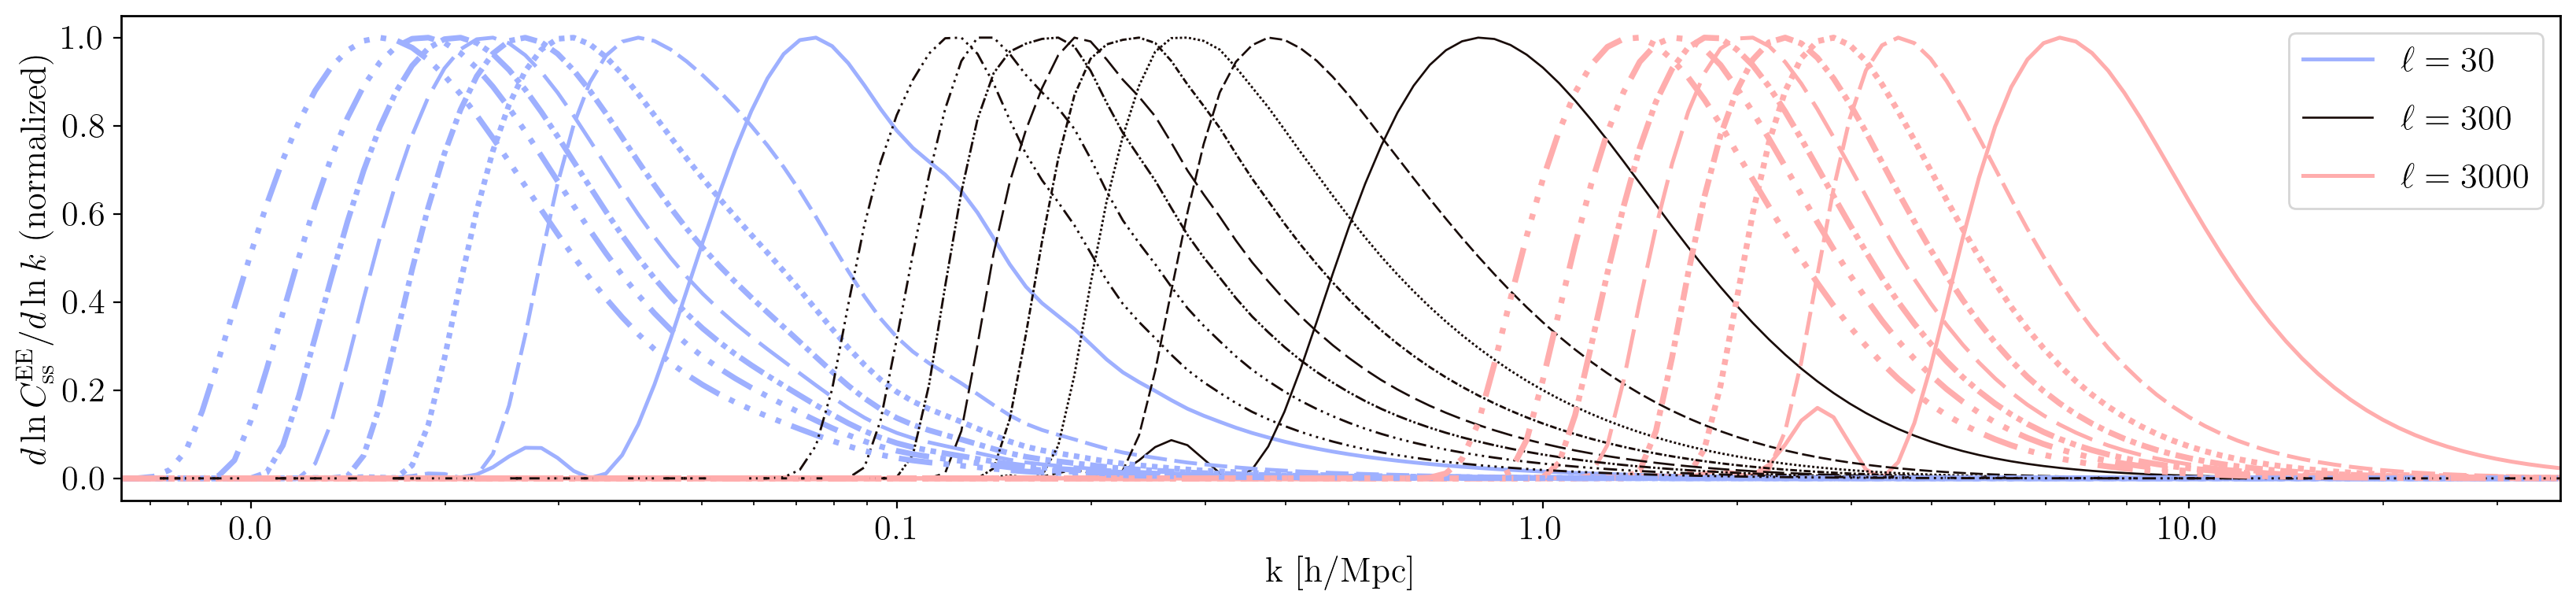

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
nmax = len(ell)
cmap = plt.cm.berlin
colors = cmap(np.linspace(0, 1, nmax))
linestyles = [
    "-",                  # solid
    (0, (6, 2)),          # long dash
    (0, (1, 1)),          # dotted
    (0, (3, 1, 1, 1)),    # dense dash-dot
    (0, (10, 3)),         # very long dash
    (0, (5, 1, 1, 1, 1, 1)),       # dash-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2)), # dash-dot-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2, 1, 2)) # dash-dot-dot-dot
]
def luminance(rgb):
    r, g, b = rgb[:3]
    return (0.2126*r + 0.7152*g + 0.0722*b)   # perceived brightness
def style_factor(ls):
    if isinstance(ls, str):
        return 1.0 # solid line: no extra thickness
    _, dashes = ls
    on_lengths = dashes[0::2]   # only the "on" segments
    mean_on = sum(on_lengths) / len(on_lengths)
    return float(np.clip(6.0 / mean_on, 1.0, 2.0))  # shorter dashes => larger factor; clamp to keep sane
labels = [r"$\ell=30$",r"$\ell=300$",r"$\ell=3000$"]
plt.figure(figsize=(20, 4))
for i in range(0, 8):
    for j, (c, lab) in enumerate(zip(colors, labels)):
        if i == 0:
            plt.plot(kk, dlnCEEdlnk[:, j, i, i]/np.max(dlnCEEdlnk[:, j, i, i]), 
                     color=c, label=lab, ls = linestyles[i % len(linestyles)], 
                     linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
        else:
            plt.plot(kk, dlnCEEdlnk[:, j, i, i]/np.max(dlnCEEdlnk[:, j, i, i]), 
                     color=c, ls = linestyles[i % len(linestyles)], 
                     linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
plt.xlabel("k [h/Mpc]", fontsize=16)
ax = plt.gca()
ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(axis="both", which="major", labelsize=16)
plt.xlim(kk[0], kk[-1])
plt.ylabel("$d\ln C_{\mathrm{ss}}^{\mathrm{EE}} / d\ln k$ (normalized)", fontsize=16) 
plt.legend(fontsize=16)
plt.show()

# Plot Reponse Function $d\ln \xi_{\pm} \big/ d\ln k$ (normalized)

In [12]:
def dlnxi_dlnk_pm_tomo_limber(k,
                              ntheta = ntheta, 
                              theta_min_arcmin = theta_min_arcmin, 
                              theta_max_arcmin = theta_max_arcmin, 
                              omegam = omegam, 
                              omegab = omegab, 
                              H0 = H0, 
                              ns = ns, 
                              As_1e9 = As_1e9, 
                              w = w, 
                              w0pwa = w0pwa,
                              A1  = [roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0], 
                              A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                              BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                              shear_photoz_bias = [roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8],
                              M = [roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6, roman_M7, roman_M8],
                              baryon_sims = None,
                              AccuracyBoost=1.0, 
                              kmax=10.0, 
                              k_per_logint=10, 
                              CAMBAccuracyBoost=1.0,
                              CLAccuracyBoost=1.0, 
                              CLIntegrationAccuracy=0,
                              non_linear_emul=non_linear_emul,
                              allsims=None):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(50000+10000*CLAccuracyBoost))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    if baryon_sims is not None and allsims is not None:
        ci.init_baryons_contamination(sim = baryon_sims, allsims=allsims)
    (dlnxip_dlnk, dlnxim_dlnk) = ci.dlnxi_dlnk_pm_tomo_limber(k=k)    
    return (ci.get_binning_real_space(), dlnxip_dlnk, dlnxim_dlnk)

In [26]:
kk = 10.0**np.arange(-3., 1.02, 0.02)

In [ ]:
(theta, dlnxip_dlnk, dlnxim_dlnk) = dlnxi_dlnk_pm_tomo_limber(k = kk)

In [ ]:
print(theta)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
nmax = 3
cmap = plt.cm.berlin
colors = cmap(np.linspace(0, 1, nmax))
linestyles = [
    "-",                  # solid
    (0, (6, 2)),          # long dash
    (0, (1, 1)),          # dotted
    (0, (3, 1, 1, 1)),    # dense dash-dot
    (0, (10, 3)),         # very long dash
    (0, (5, 1, 1, 1, 1, 1)),       # dash-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2)), # dash-dot-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2, 1, 2)) # dash-dot-dot-dot
]
def luminance(rgb):
    r, g, b = rgb[:3]
    return 0.2126*r + 0.7152*g + 0.0722*b   # perceived brightness
def style_factor(ls):
    if isinstance(ls, str):
        return 1.0 # solid line: no extra thickness
    _, dashes = ls
    on_lengths = dashes[0::2]   # only the "on" segments
    mean_on = sum(on_lengths) / len(on_lengths)
    return float(np.clip(6.0 / mean_on, 1.0, 2.0))  # shorter dashes => larger factor; clamp to keep sane
labels = [r"$\theta=10.148$'",r"$\theta=160.8$'"]
idx = [4,13]
plt.figure(figsize=(20, 4))
for i in range(0, 8):
  for j, (c, lab) in enumerate(zip(colors, labels)):
      if i == 0:
          plt.plot(kk, dlnxip_dlnk[:,idx[j], i, i]/np.max(dlnxip_dlnk[:,idx[j], i, i]), 
                   color=c, label=lab, ls = linestyles[i % len(linestyles)], 
                   linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
      else:
          plt.plot(kk, dlnxip_dlnk[:,idx[j], i, i]/np.max(dlnxip_dlnk[:,idx[j], i, i]), 
                   color=c, ls = linestyles[i % len(linestyles)], 
                   linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
plt.xlabel("k [h/Mpc]", fontsize=16)
ax = plt.gca()
ax.set_xscale("log")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.2g}")
)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(axis="both", which="major", labelsize=16)
plt.xlim(kk[0], kk[-1])
plt.ylabel("$d\ln \\xi_{+} / d\ln k$ (normalized)", fontsize=16) 
plt.legend(fontsize=16)
plt.show()

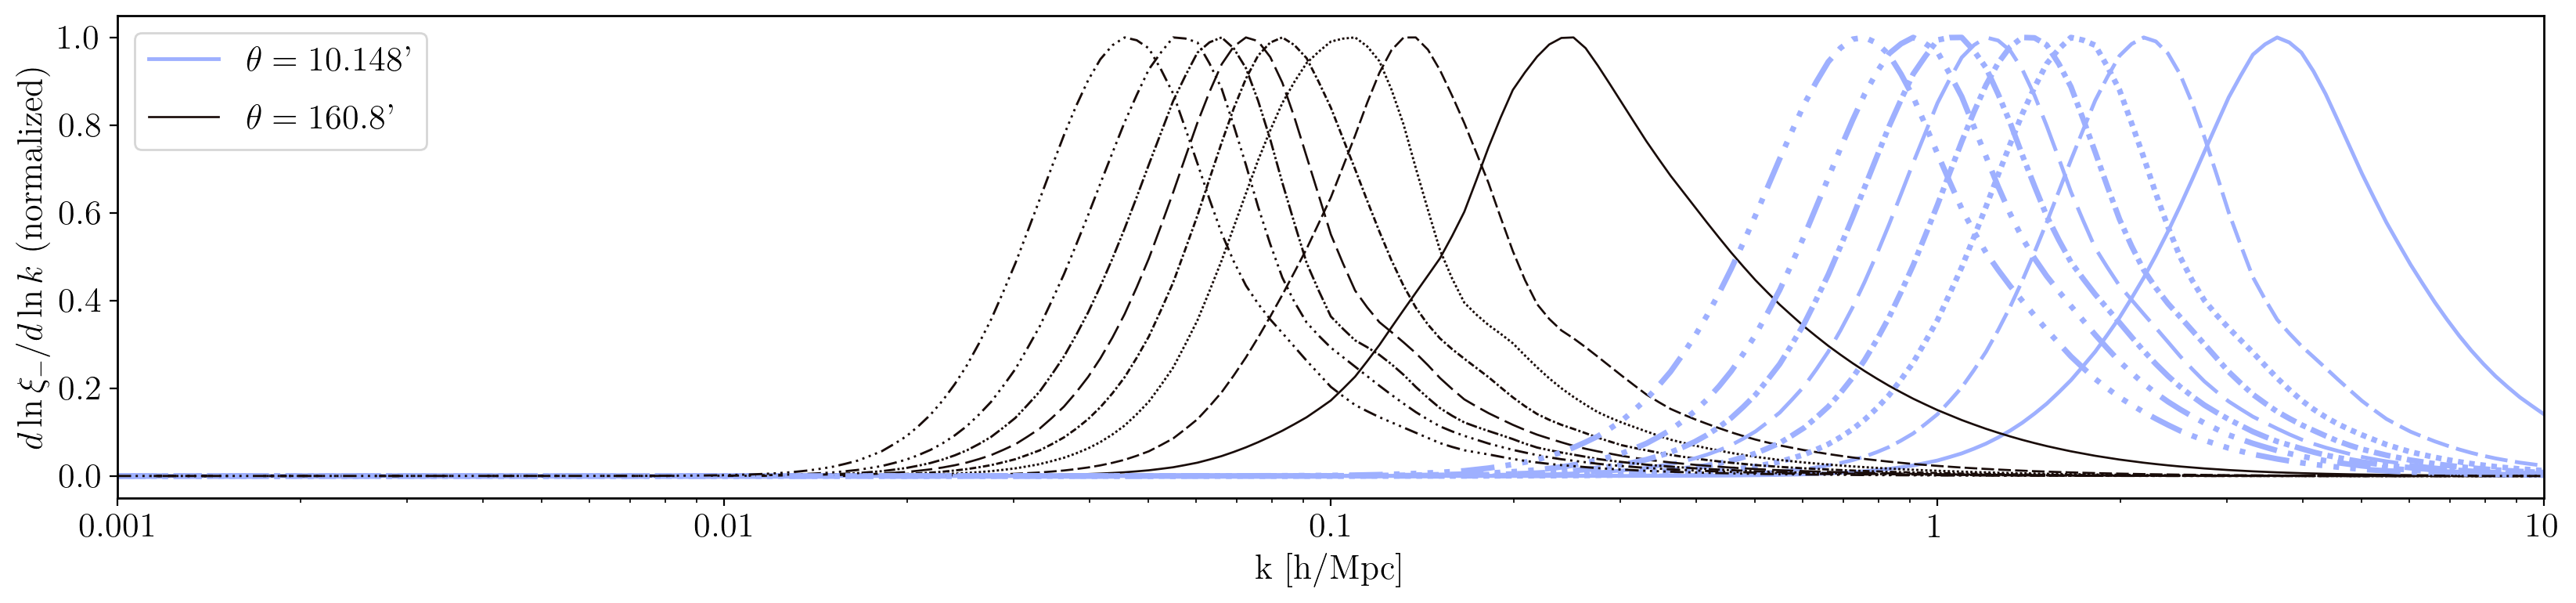

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
nmax = 3
cmap = plt.cm.berlin
colors = cmap(np.linspace(0, 1, nmax))
linestyles = [
    "-",                  # solid
    (0, (6, 2)),          # long dash
    (0, (1, 1)),          # dotted
    (0, (3, 1, 1, 1)),    # dense dash-dot
    (0, (10, 3)),         # very long dash
    (0, (5, 1, 1, 1, 1, 1)),       # dash-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2)), # dash-dot-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2, 1, 2)) # dash-dot-dot-dot
]
def luminance(rgb):
    r, g, b = rgb[:3]
    return 0.2126*r + 0.7152*g + 0.0722*b   # perceived brightness
def style_factor(ls):
    if isinstance(ls, str):
        return 1.0 # solid line: no extra thickness
    _, dashes = ls
    on_lengths = dashes[0::2]   # only the "on" segments
    mean_on = sum(on_lengths) / len(on_lengths)
    return float(np.clip(6.0 / mean_on, 1.0, 2.0))  # shorter dashes => larger factor; clamp to keep sane
labels = [r"$\theta=10.148$'",r"$\theta=160.8$'"]
idx = [4,13]
plt.figure(figsize=(20, 4))
for i in range(0, 8):
  for j, (c, lab) in enumerate(zip(colors, labels)):
      if i == 0:
          plt.plot(kk, dlnxim_dlnk[:,idx[j], i, i]/np.max(dlnxim_dlnk[:,idx[j], i, i]), 
                   color=c, label=lab, ls = linestyles[i % len(linestyles)], 
                   linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
      else:
          plt.plot(kk, dlnxim_dlnk[:,idx[j], i, i]/np.max(dlnxim_dlnk[:,idx[j], i, i]), 
                   color=c, ls = linestyles[i % len(linestyles)], 
                   linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
plt.xlabel("k [h/Mpc]", fontsize=16)
ax = plt.gca()
ax.set_xscale("log")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.2g}")
)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(axis="both", which="major", labelsize=16)
plt.xlim(kk[0], kk[-1])
plt.ylabel("$d\ln \\xi_{-} / d\ln k$ (normalized)", fontsize=16) 
plt.legend(fontsize=16)
plt.show()

# Plot Reponse Function $\int_{-\infty}^{\ln k_\alpha} d\ln k \big|d\ln C_{\mathrm{ss}}^{\mathrm{EE}} (\ell)\big/d\ln k\big| \bigg/ \int_{-\infty}^{\infty} d\ln k \big|d\ln C_{\mathrm{ss}}^{\mathrm{EE}}(\ell) \big/d\ln k\big|$ as a function of $k_\alpha$

In [18]:
def rf_C_ss_tomo_limber(k,
                          ell, 
                          omegam = omegam, 
                          omegab = omegab, 
                          H0 = H0, 
                          ns = ns, 
                          As_1e9 = As_1e9, 
                          w = w, 
                          w0pwa = w0pwa,
                          A1  = [roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0], 
                          A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                          BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                          shear_photoz_bias = [roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, 
                                               roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8],
                          M = [roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6, roman_M7, roman_M8],
                          baryon_sims = None,
                          AccuracyBoost = 1.0, 
                          kmax = 10.0, 
                          k_per_logint = 10, 
                          CAMBAccuracyBoost=1.0,
                          CLAccuracyBoost = 1.0, 
                          CLIntegrationAccuracy=0,
                          non_linear_emul=non_linear_emul,
                          allsims=None):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.set_cosmology(omegam=omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    if baryon_sims is not None and allsims is not None:
        ci.init_baryons_contamination(sim = baryon_sims, allsims=allsims)
    return ci.rf_C_ss_tomo_limber(k = k, l = ell)

In [19]:
ell  = [30.,300.,3000.]
kk = 10.0 ** np.arange(-2.2, 1.6, 0.05)
(rfCEE, tmp) = rf_C_ss_tomo_limber(k=kk, ell=ell, CLAccuracyBoost=1.00, CLIntegrationAccuracy=0)

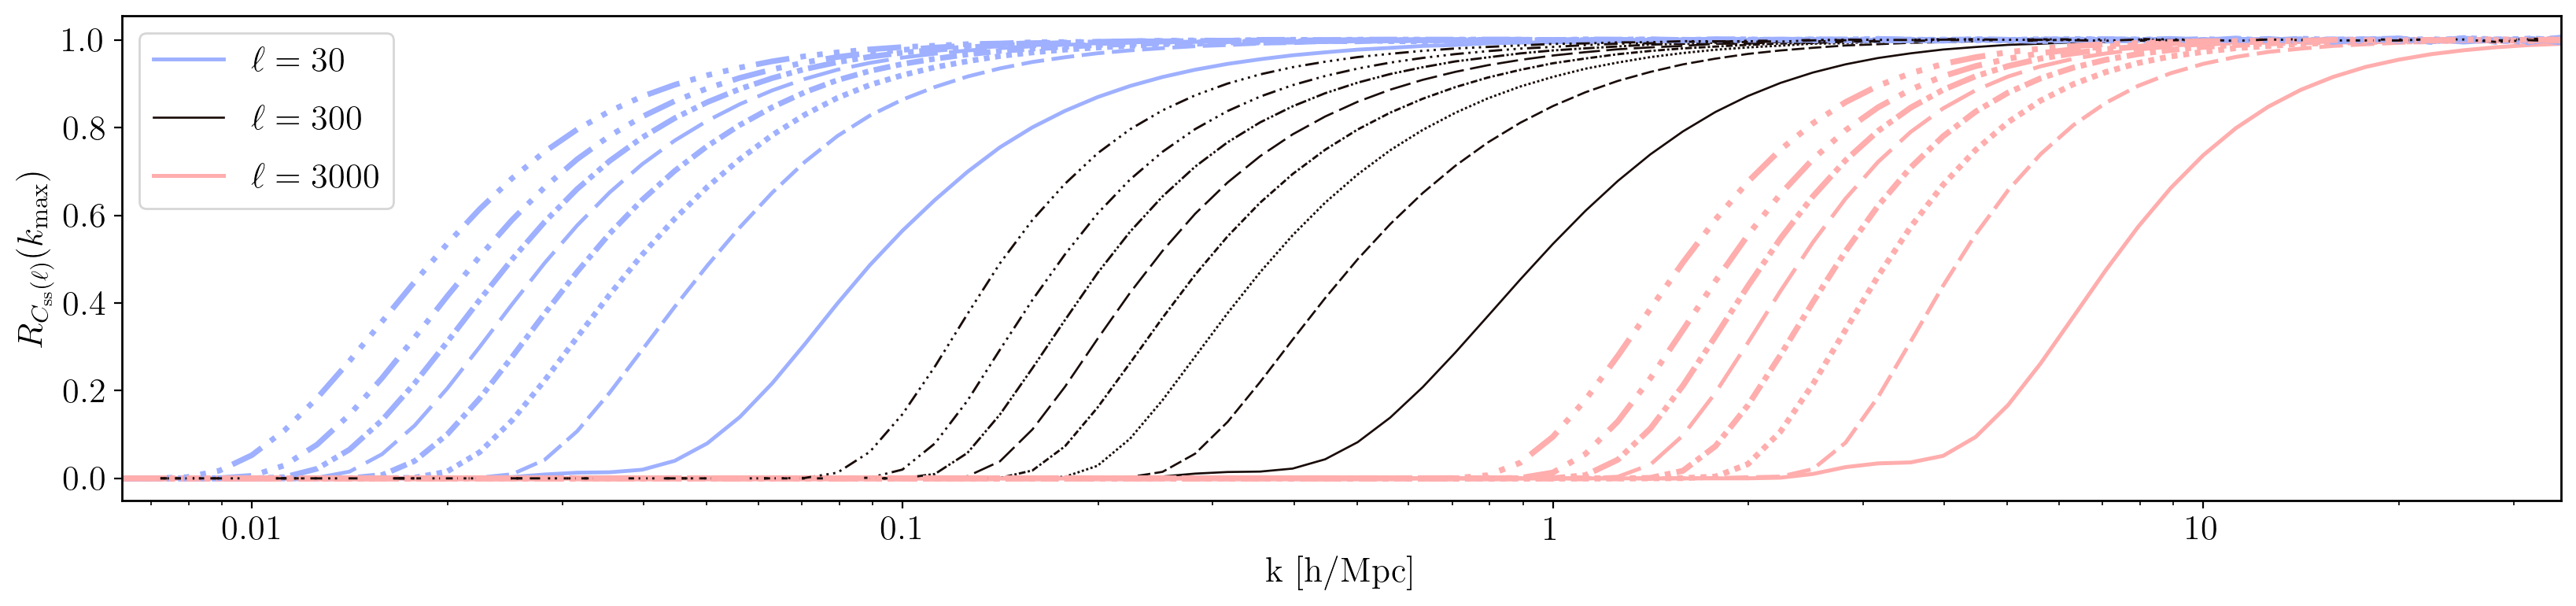

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
nmax = len(ell)
cmap = plt.cm.berlin
colors = cmap(np.linspace(0, 1, nmax))
linestyles = [
    "-",                  # solid
    (0, (6, 2)),          # long dash
    (0, (1, 1)),          # dotted
    (0, (3, 1, 1, 1)),    # dense dash-dot
    (0, (10, 3)),         # very long dash
    (0, (5, 1, 1, 1, 1, 1)),       # dash-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2)), # dash-dot-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2, 1, 2)) # dash-dot-dot-dot
]
def luminance(rgb):
    r, g, b = rgb[:3]
    return (0.2126*r + 0.7152*g + 0.0722*b)   # perceived brightness
def style_factor(ls):
    if isinstance(ls, str):
        return 1.0 # solid line: no extra thickness
    _, dashes = ls
    on_lengths = dashes[0::2]   # only the "on" segments
    mean_on = sum(on_lengths) / len(on_lengths)
    return float(np.clip(6.0 / mean_on, 1.0, 2.0))  # shorter dashes => larger factor; clamp to keep sane
labels = [r"$\ell=30$",r"$\ell=300$",r"$\ell=3000$"]
plt.figure(figsize=(20, 4))
for i in range(0, 8):
    for j, (c, lab) in enumerate(zip(colors, labels)):
        if i == 0:
            plt.plot(kk, rfCEE[:, j, i, i], 
                     color=c, label=lab, ls = linestyles[i % len(linestyles)], 
                     linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
        else:
            plt.plot(kk, rfCEE[:, j, i, i], 
                     color=c, ls = linestyles[i % len(linestyles)], 
                     linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
plt.xlabel("k [h/Mpc]", fontsize=16)
ax = plt.gca()
ax.set_xscale("log")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.2g}")
)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(axis="both", which="major", labelsize=16)
plt.xlim(kk[0], kk[-1])
plt.ylabel("$R_{C_{\mathrm{ss}}(\ell)}(k_{\mathrm{max}})$", fontsize=16) 
plt.legend(fontsize=16)
plt.show()

# Plot Reponse Function $\int_{-\infty}^{\ln k_\alpha} d\ln k \big|d\ln \xi_{\pm} (\theta)\big/d\ln k\big| \bigg/ \int_{-\infty}^{\infty} d\ln k \big|d\ln \xi_{\pm}(\ell) \big/d\ln k\big|$ as a function of $k_\alpha$

In [21]:
def rf_xi_tomo_limber(k,
                      ntheta = ntheta, 
                      theta_min_arcmin = theta_min_arcmin, 
                      theta_max_arcmin = theta_max_arcmin, 
                      omegam = omegam, 
                      omegab = omegab, 
                      H0 = H0, 
                      ns = ns, 
                      As_1e9 = As_1e9, 
                      w = w, 
                      w0pwa = w0pwa,
                      A1  = [roman_A1_1, roman_A1_2, 0, 0, 0, 0, 0, 0], 
                      A2  = [0, 0, 0, 0, 0, 0, 0, 0],
                      BTA = [0, 0, 0, 0, 0, 0, 0, 0],
                      shear_photoz_bias = [roman_DZ_S1, roman_DZ_S2, roman_DZ_S3, roman_DZ_S4, roman_DZ_S5, roman_DZ_S6, roman_DZ_S7, roman_DZ_S8],
                      M = [roman_M1, roman_M2, roman_M3, roman_M4, roman_M5, roman_M6, roman_M7, roman_M8],
                      baryon_sims = None,
                      AccuracyBoost=1.0, 
                      kmax=10.0, 
                      k_per_logint=10, 
                      CAMBAccuracyBoost=1.0,
                      CLAccuracyBoost=1.0, 
                      CLIntegrationAccuracy=0,
                      non_linear_emul=non_linear_emul,
                      allsims=None):

    (log10k_interp_2D, z_interp_2D, lnPL, lnPNL, G_growth, z_interp_1D, chi) = get_camb_cosmology(omegam=omegam, 
                                                                                                  omegab=omegab, 
                                                                                                  H0=H0, 
                                                                                                  ns=ns, 
                                                                                                  As_1e9=As_1e9, 
                                                                                                  w=w, 
                                                                                                  w0pwa=w0pwa,
                                                                                                  AccuracyBoost=AccuracyBoost,
                                                                                                  kmax=kmax,
                                                                                                  k_per_logint=k_per_logint,
                                                                                                  CAMBAccuracyBoost=CAMBAccuracyBoost,
                                                                                                  non_linear_emul=non_linear_emul)
    CLAccuracyBoost = CLAccuracyBoost * AccuracyBoost
    CLIntegrationAccuracy = max(0, CLIntegrationAccuracy + abs(3*(CLAccuracyBoost-1.0)))
    ci.init_ntable_lmax(int(50000+10000*CLAccuracyBoost))
    ci.init_accuracy_boost(CLAccuracyBoost, int(CLIntegrationAccuracy))
    ci.init_binning(int(ntheta), theta_min_arcmin, theta_max_arcmin)
    ci.set_cosmology(omegam = omegam, 
                     H0 = H0, 
                     log10k_2D = log10k_interp_2D, 
                     z_2D = z_interp_2D, 
                     lnP_linear = lnPL,
                     lnP_nonlinear = lnPNL,
                     G = G_growth,
                     z_1D = z_interp_1D,
                     chi = chi)
    ci.set_nuisance_shear_calib(M = M)
    ci.set_nuisance_shear_photoz(bias = shear_photoz_bias)
    ci.set_nuisance_ia(A1 = A1, A2 = A2, B_TA = BTA)

    if baryon_sims is None:
        ci.reset_bary_struct()
    if baryon_sims is not None and allsims is not None:
        ci.init_baryons_contamination(sim = baryon_sims, allsims=allsims)
    (rf_xip, rf_xim) = ci.rf_xi_tomo_limber(k=k)   
    return (ci.get_binning_real_space(), rf_xip, rf_xim)   

In [22]:
kk = 10.0 ** np.arange(-2, 1.2, 0.02)

In [23]:
(theta, rf_xip, rf_xim) = rf_xi_tomo_limber(k = kk)

In [24]:
print(theta)

[2.97200132245545, 4.0400089913792465, 5.491812041638084, 7.465329796304372, 10.148043768622234, 13.794808151791631, 18.75206062208114, 25.490733448767543, 34.65099142176315, 47.1030466394507, 64.02982747918657, 87.03935519068173, 118.31750373639919, 160.835654856868, 218.63297531081636]


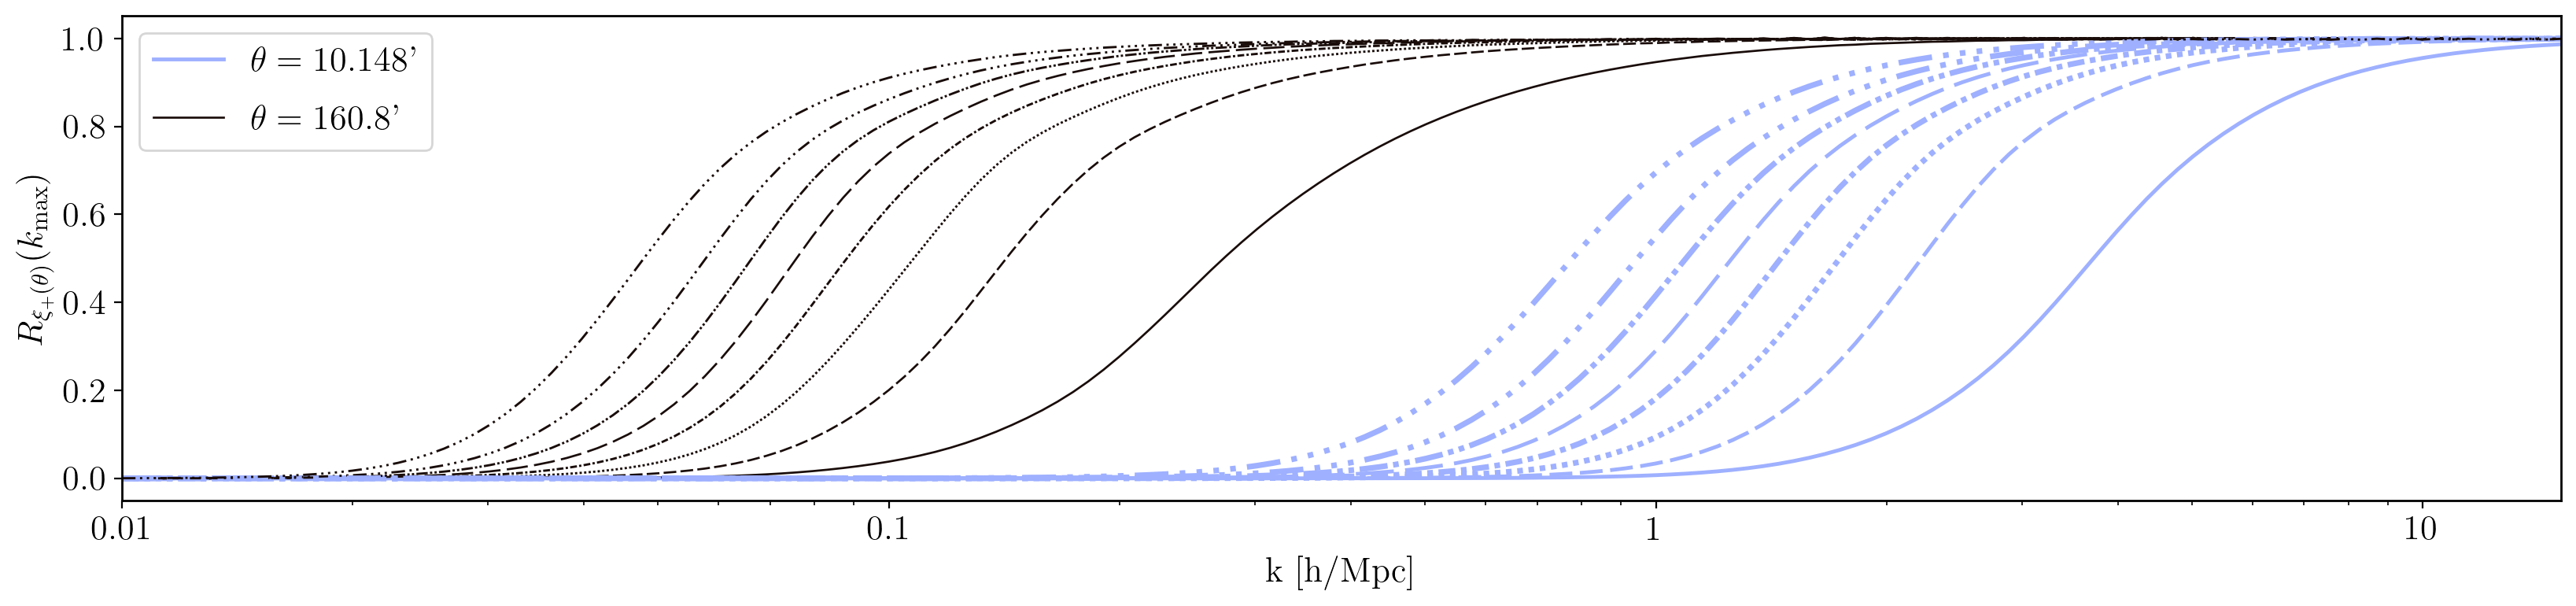

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
nmax = 3
cmap = plt.cm.berlin
colors = cmap(np.linspace(0, 1, nmax))
linestyles = [
    "-",                  # solid
    (0, (6, 2)),          # long dash
    (0, (1, 1)),          # dotted
    (0, (3, 1, 1, 1)),    # dense dash-dot
    (0, (10, 3)),         # very long dash
    (0, (5, 1, 1, 1, 1, 1)),       # dash-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2)), # dash-dot-dot-dot
    (0, (6, 2, 1, 2, 1, 2, 1, 2, 1, 2)) # dash-dot-dot-dot
]
def luminance(rgb):
    r, g, b = rgb[:3]
    return 0.2126*r + 0.7152*g + 0.0722*b   # perceived brightness
def style_factor(ls):
    if isinstance(ls, str):
        return 1.0 # solid line: no extra thickness
    _, dashes = ls
    on_lengths = dashes[0::2]   # only the "on" segments
    mean_on = sum(on_lengths) / len(on_lengths)
    return float(np.clip(6.0 / mean_on, 1.0, 2.0))  # shorter dashes => larger factor; clamp to keep sane
labels = [r"$\theta=10.148$'",r"$\theta=160.8$'"]
idx = [4,13]
plt.figure(figsize=(20, 4))
for i in range(0, 8):
  for j, (c, lab) in enumerate(zip(colors, labels)):
      if i == 0:
          plt.plot(kk, rf_xip[:,idx[j], i, i], 
                   color=c, label=lab, ls = linestyles[i % len(linestyles)], 
                   linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
      else:
          plt.plot(kk, rf_xip[:,idx[j], i, i],
                   color=c, ls = linestyles[i % len(linestyles)], 
                   linewidth=0.9+1.2*luminance(c)*style_factor(linestyles[i%len(linestyles)]))
plt.xlabel("k [h/Mpc]", fontsize=16)
ax = plt.gca()
ax.set_xscale("log")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.2g}")
)
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.tick_params(axis="both", which="major", labelsize=16)
plt.xlim(kk[0], kk[-1])
plt.ylabel("$R_{\\xi_+(\\theta)}(k_{\mathrm{max}})$", fontsize=16) 
plt.legend(fontsize=16)
plt.show()